# Data Cleaning and Inspection 

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("./Data/Online Retail Dataset.csv", encoding="latin-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Data description 
- One customer can have multiple transactions
- One invoice is one transanction 
- If one customer buys multiple products i.e same invoice no and customer ID 

In [4]:
# In RFM we have Recency, Frequecy and Monetary 
# Frequency - count of invoices per customer 
# Recency - last invoice date 
# Monetary - total spend across all invoices 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df["Description"].value_counts().head(10)

WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: Description, dtype: int64

In [8]:
# percentage of missing values in the description column 
1454/541909 * 100 

0.2683107311375157

In [9]:
df = df.dropna(subset=['Description'])

In [10]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

In [11]:
# Percentage of missing values in the customers Id column 
133626 /541909 * 100 

24.658383603151083

In [12]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [13]:
df = df.dropna(subset=['CustomerID'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    406829 non-null  object 
 1   StockCode    406829 non-null  object 
 2   Description  406829 non-null  object 
 3   Quantity     406829 non-null  int64  
 4   InvoiceDate  406829 non-null  object 
 5   UnitPrice    406829 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      406829 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.9+ MB


In [15]:
df.shape

(406829, 8)

In [16]:
# Checking for negative quantity (returned items or cancelled transactions)
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [17]:
# Filtered the returned items to focus on customer purchasing behaviour 
# Retained quatity that is greater than 0
df = df[df["Quantity"] > 0]

In [18]:
# confirmation of filtering 
df[df['Quantity'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


Transactions with negative quantities were identified as returns and excluded from the analysis to ensure that customer value metrics reflect actual purchasing behavior.

In [19]:
# Checking for duplicates 
df.duplicated().sum()

5192

In [20]:
# Dropped duplicates based on Key columns in the dataset
df = df.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'CustomerID', 'Quantity', 'InvoiceDate'])

In [21]:
df.duplicated().sum()

0

Duplicate transaction rows were identified and removed to prevent inflation of customer-level metrics such as frequency and monetary value in the RFM analysis.

In [22]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,12/5/2010 14:02,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,12/16/2010 14:36,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,12/21/2010 13:45,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,1/6/2011 16:41,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,1/6/2011 16:41,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,1/13/2011 15:10,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2/10/2011 13:08,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,3/23/2011 10:25,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,3/30/2011 12:45,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,4/4/2011 14:42,0.0,14410.0,United Kingdom


In [23]:
df[df['UnitPrice'] == 0].head()
df['UnitPrice'].describe()

count    392708.000000
mean          3.105736
std          21.518804
min           0.000000
25%           1.250000
50%           1.950000
75%           3.750000
max        8142.750000
Name: UnitPrice, dtype: float64

Summary:
- min= 0.00 some items are free or invalid
- median = 1.95 most products are cheap
- 75% = 3.75 majority are low priced products 
- max = 8142.75 This is an extreme outlier 

In [24]:
# Filtered items with a unit price of zero 
df = df[df["UnitPrice"] > 0]

In [25]:
# confirmation of filtering 
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [26]:
# Saving of the cleaned dataset
df.to_csv("cleaned_transactions.csv", index=False)

# Feature Engineering 

In [27]:
df_cleaned = pd.read_csv("Data/cleaned_transactions.csv")
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [28]:
df_cleaned.dtypes

InvoiceNo        int64
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
TotalPrice     float64
dtype: object

In [29]:
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

In [30]:
snapshot_date = df_cleaned['InvoiceDate'].max()

recency = snapshot_date - df_cleaned.groupby('CustomerID')['InvoiceDate'].max()

In [31]:
df_cleaned.dtypes

InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
TotalPrice            float64
dtype: object

In [32]:
df_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [33]:
# Creation of the Total Price column 
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

In [34]:
rfm = df_cleaned.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [35]:
rfm.to_csv("customer_rfm.csv")

In [36]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,1,77183.60
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [37]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Float64Index: 4338 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Recency    4338 non-null   int64  
 1   Frequency  4338 non-null   int64  
 2   Monetary   4338 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 135.6 KB


In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline


In [41]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('KMeans', KMeans(n_clusters=4, random_state=42))
])
features = rfm[['Recency', 'Frequency','Monetary']]

rfm['Cluster'] = pipe.fit_predict(features)

c:\Users\hp\anaconda3\envs\learn-env\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


“A pipeline was implemented to standardize customer features and apply K-Means clustering, ensuring a consistent and reproducible segmentation workflow.”

## Cluster Interpretation

In [42]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,42.878193,3.663392,1351.615060
1,247.469426,1.553151,478.625711
2,6.384615,82.538462,127169.376154
3,14.384615,22.206731,12445.836490


Each row represents the average customer behavior in that cluster. The metrics of measure are as follows:
- Recency - Lower = more recent(good for business, customer is still engaged)
- Frequency - Higher = buys more often 
- Monetary - Higher = spends more(Bulk buying for business or big spenders)

### Cluster 2 → VIP / High-Value Customers
Recency: 6 days (very recent)
Frequency: 82 (extremely frequent)
Monetary: 127,169 (very high spend)

Your best customers
Highly engaged + high revenue

Business meaning:
Core revenue drivers
Likely loyal or business buyers

Action:
Retain at all costs
Offer loyalty rewards / exclusives

### Cluster 3 → Loyal Customers
Recency: 14 days
Frequency: 22
Monetary: 12,445

Strong, consistent customers
Not as extreme as VIPs but still valuable

Business meaning:
Reliable revenue base

Action:
Upsell / cross-sell
Move them toward VIP segment

### Cluster 0 → Potential Loyal / Mid-Value
Recency: 42 days
Frequency: 3.6
Monetary: 1,351

Occasional buyers
Moderate spend

Business meaning:
Growth opportunity segment

Action:
Targeted marketing
Engagement campaigns

### Cluster 1 → At-Risk / Low-Value Customers
Recency: 247 days (haven’t purchased in a long time)
Frequency: 1.5
Monetary: 478

Almost inactive
Low engagement
Business meaning:

High churn risk

Action:
Reactivation campaigns
Discounts or reminders

Customer segmentation revealed four distinct behavioral groups ranging from low-engagement, at-risk customers to high-value, highly active customers. The segmentation enables targeted marketing strategies tailored to each group’s engagement and value profile.

In [ ]:
# Segmenting the customers according to clusters
rfm['Segment'] = rfm['Cluster'].map({
    2: 'VIP',
    3: 'Loyal',
    0: 'Potential',
    1: 'At Risk'
})
rfm

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346.0,325,1,77183.60,3,Loyal
12347.0,1,7,4310.00,0,Potential
12348.0,74,4,1797.24,0,Potential
12349.0,18,1,1757.55,0,Potential
12350.0,309,1,334.40,1,At Risk
...,...,...,...,...,...
18280.0,277,1,180.60,1,At Risk
18281.0,180,1,80.82,1,At Risk
18282.0,7,2,178.05,0,Potential


In [ ]:
# I want to create a mapping for the monetary factor that is spending patterns low and high spenders
# create a spending category by feature engineering 

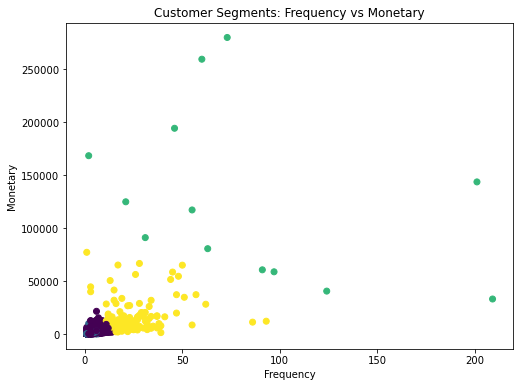

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(rfm['Frequency'], rfm['Monetary'], c=rfm['Cluster'])
plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segments: Frequency vs Monetary')
plt.show()

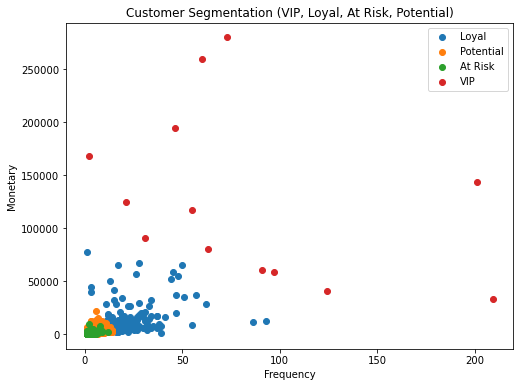

In [49]:
plt.figure(figsize=(8,6))

for segment in rfm['Segment'].unique():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Frequency'], subset['Monetary'], label=segment)

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segmentation (VIP, Loyal, At Risk, Potential)')
plt.legend()
plt.show()

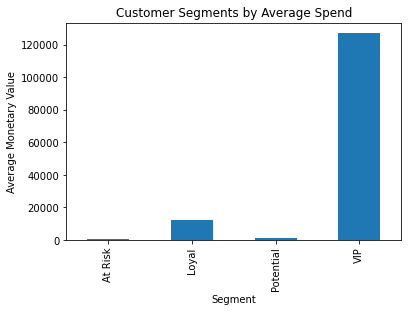

In [50]:
rfm.groupby('Segment')['Monetary'].mean().plot(kind='bar')

plt.title('Customer Segments by Average Spend')
plt.ylabel('Average Monetary Value')
plt.xlabel('Segment')
plt.show()

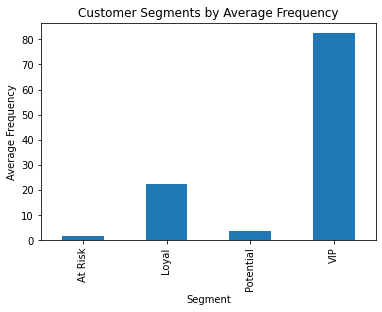

In [51]:
rfm.groupby('Segment')['Frequency'].mean().plot(kind='bar')

plt.title('Customer Segments by Average Frequency')
plt.ylabel('Average Frequency')
plt.xlabel('Segment')
plt.show()

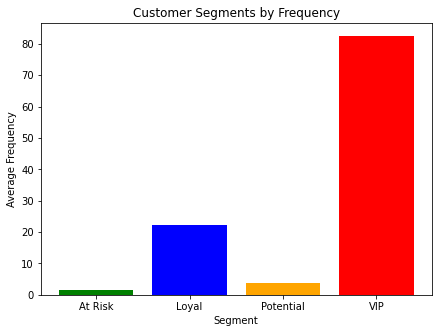

In [53]:


freq = rfm.groupby('Segment')['Frequency'].mean()

colors = ['green', 'blue', 'orange', 'red']

plt.figure(figsize=(7,5))
plt.bar(freq.index, freq.values, color=colors)

plt.title('Customer Segments by Frequency')
plt.xlabel('Segment')
plt.ylabel('Average Frequency')

plt.show()

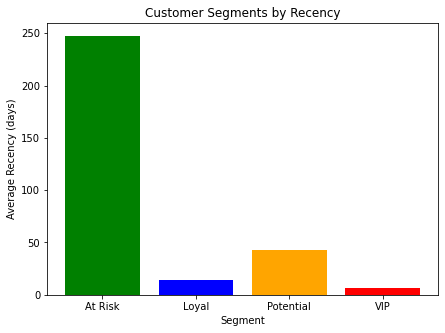

In [54]:
rec = rfm.groupby('Segment')['Recency'].mean()

colors = ['green', 'blue', 'orange', 'red']

plt.figure(figsize=(7,5))
plt.bar(rec.index, rec.values, color=colors)

plt.title('Customer Segments by Recency')
plt.xlabel('Segment')
plt.ylabel('Average Recency (days)')

plt.show()

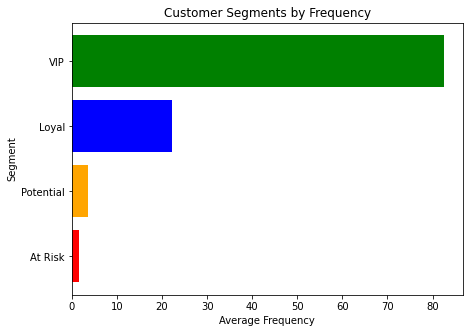

In [55]:
color_map = {
    'VIP': 'green',
    'Loyal': 'blue',
    'Potential': 'orange',
    'At Risk': 'red'
}

freq = rfm.groupby('Segment')['Frequency'].mean().sort_values()

plt.figure(figsize=(7,5))
plt.barh(freq.index, freq.values, color=[color_map[s] for s in freq.index])

plt.title('Customer Segments by Frequency')
plt.xlabel('Average Frequency')
plt.ylabel('Segment')

plt.show()

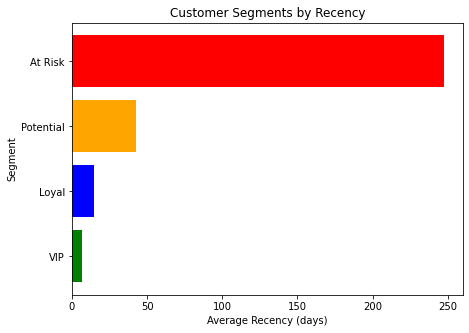

In [56]:
rec = rfm.groupby('Segment')['Recency'].mean().sort_values()

plt.figure(figsize=(7,5))
plt.barh(rec.index, rec.values, color=[color_map[s] for s in rec.index])

plt.title('Customer Segments by Recency')
plt.xlabel('Average Recency (days)')
plt.ylabel('Segment')

plt.show()